In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("../data/clean/customers_clean.csv")

In [2]:
customers.head()
customers.shape
customers.info()
customers.describe()
customers["customer_since"]=pd.to_datetime(customers["customer_since"])

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       75000 non-null  str  
 1   first_name        75000 non-null  str  
 2   last_name         75000 non-null  str  
 3   gender            75000 non-null  str  
 4   age               75000 non-null  int64
 5   marital_status    75000 non-null  str  
 6   occupation        75000 non-null  str  
 7   annual_income     75000 non-null  int64
 8   city              75000 non-null  str  
 9   state             75000 non-null  str  
 10  customer_since    75000 non-null  str  
 11  customer_segment  75000 non-null  str  
 12  customer_tenure   75000 non-null  int64
dtypes: int64(3), str(10)
memory usage: 7.4 MB


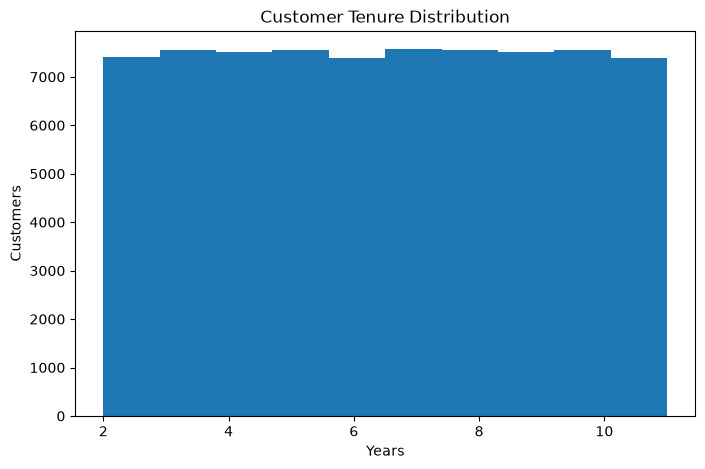

In [4]:
plt.figure(figsize=(8,5))
plt.hist(customers["customer_tenure"], bins=10)

plt.title("Customer Tenure Distribution")
plt.xlabel("Years")
plt.ylabel("Customers")

plt.show()

Main Takeaways
High Retention: The bank does not see a steep drop-off in long-term customers. People who joined 10 years ago are staying at virtually the same rate as newer customers.

Predictable Base: The stability across tenure cohorts aligns closely with the earlier yearly acquisition trend (~7,400–7,500 new customers per year), indicating steady customer loyalty and minimal churn over time.

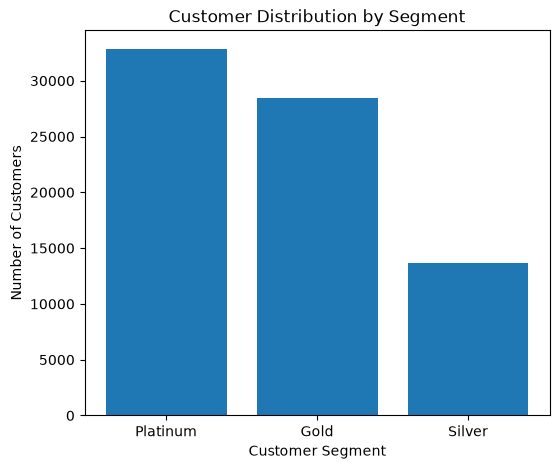

customer_segment
Platinum    32856
Gold        28446
Silver      13698
Name: count, dtype: int64

In [10]:
segment_counts = customers["customer_segment"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

segment_counts

The Platinum segment represents the largest portion of customers, indicating the bank's primary customer base.

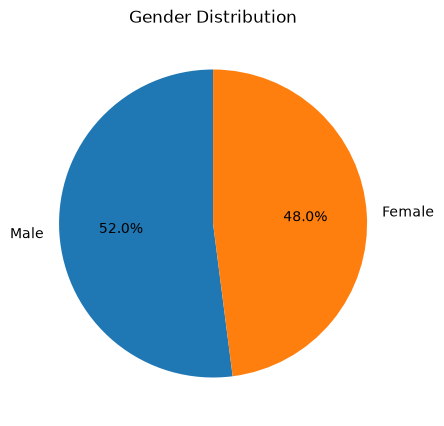

In [11]:
gender_counts = customers["gender"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

In [5]:
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[20,30,40,50,60,70],
    labels=[
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70"
    ]
)

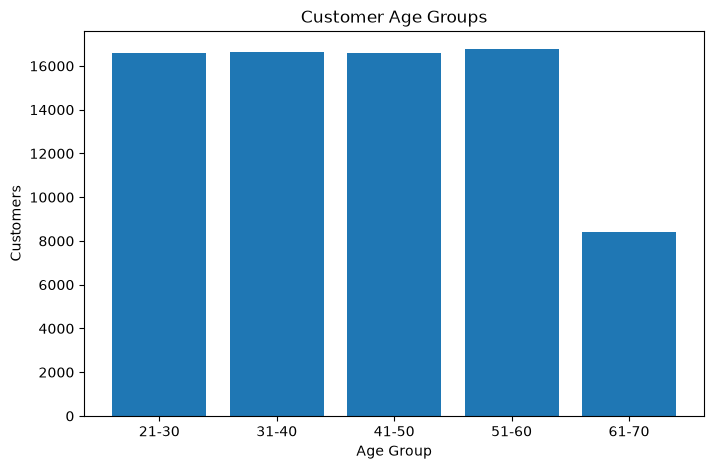

In [6]:
age_group = customers["age_group"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(age_group.index.astype(str), age_group.values)

plt.title("Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Customers")

plt.show()

Broad Core Base: The bank caters steadily to adults across all major career stages, from young professionals entering the workforce up through pre-retirees.

Retirement Transition: The decline in the 61–70 bracket likely corresponds to retirement, reduced credit need, or account consolidation into specialized pension/senior banking services

The customer base includes adults of different age groups, with most customers being middle-aged and no unusual age patterns observed.

Most customers fall between 32 and 54 years, indicating the bank primarily serves working-age individuals.

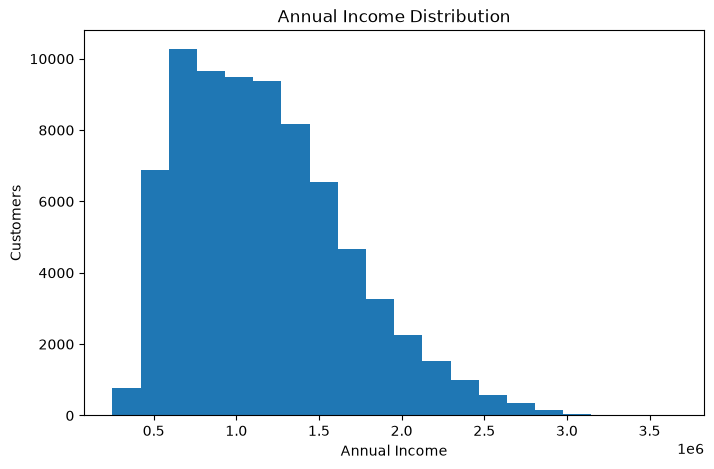

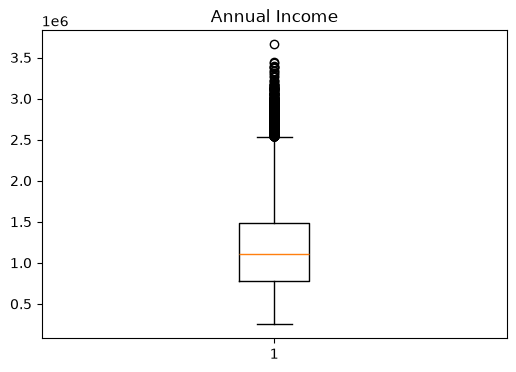

In [15]:
plt.figure(figsize=(8,5))
plt.hist(customers["annual_income"], bins=20)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Customers")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(customers["annual_income"])
plt.title("Annual Income")
plt.show()

Insight

The income distribution is expected to be right-skewed, with a smaller number of high-income customers.

Most customers have an annual income between $800,000 and $1,500,000, while only a small number earn significantly higher incomes.

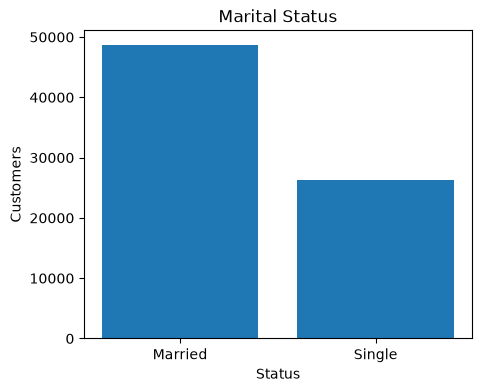

marital_status
Married    48653
Single     26347
Name: count, dtype: int64

In [16]:
marital = customers["marital_status"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(marital.index, marital.values)

plt.title("Marital Status")
plt.xlabel("Status")
plt.ylabel("Customers")
plt.show()

marital

Comparison & Key Insights
Dominant Group: Married customers dominate the customer base by a significant margin.

Ratio: There are almost twice as many married customers as single customers (nearly a 2:1 ratio).

Proportions: Married individuals make up roughly two-thirds (~65%) of the overall customer population, while single individuals account for approximately one-third (~35%).

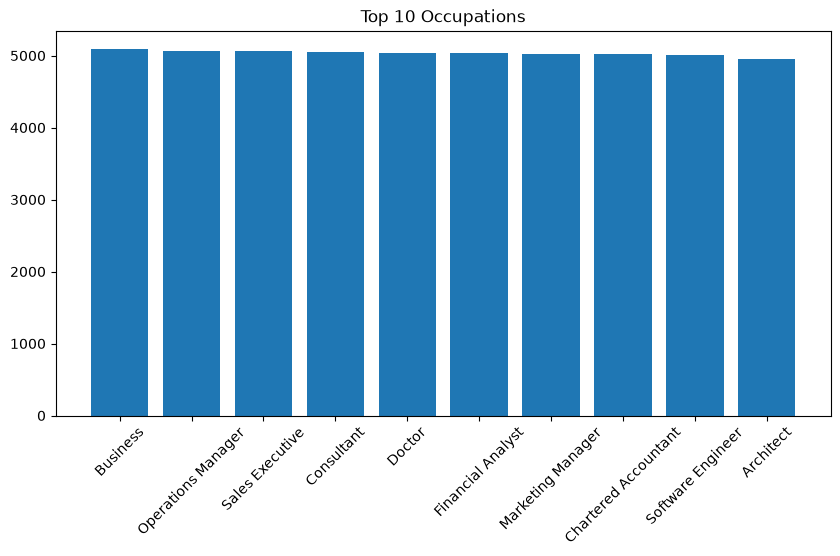

In [18]:
occupation = customers["occupation"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(occupation.index, occupation.values)

plt.xticks(rotation=45)

plt.title("Top 10 Occupations")

plt.show()

Balanced & High-Earning: The bank's top customers are well-paid professionals like doctors, engineers, accountants, and business owners, with about 5,000 people in each group.

Low Risk: Because no single job type dominates, the bank is safe from downturns in any one industry.

Prime Opportunities: This affluent customer base is ideal for premium services like wealth management, business loans, and high-tier credit cards.

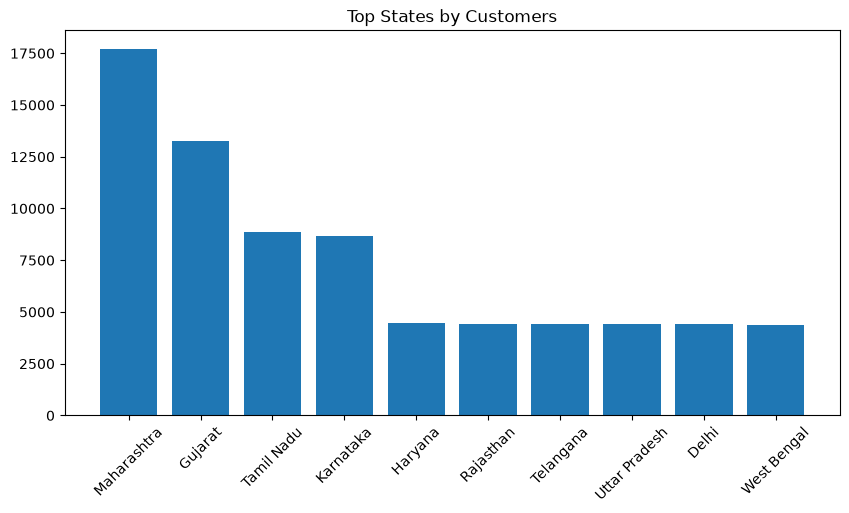

In [19]:
state = customers["state"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(state.index, state.values)

plt.xticks(rotation=45)

plt.title("Top States by Customers")

plt.show()

Key Takeaway: The top 2 states (Maharashtra and Gujarat) account for the lion's share of the customer base, followed by a solid presence in southern hubs (Tamil Nadu and Karnataka). All remaining states (Haryana, Rajasthan, Telangana, UP, Delhi, West Bengal) hover evenly at around 4,400 customers each.

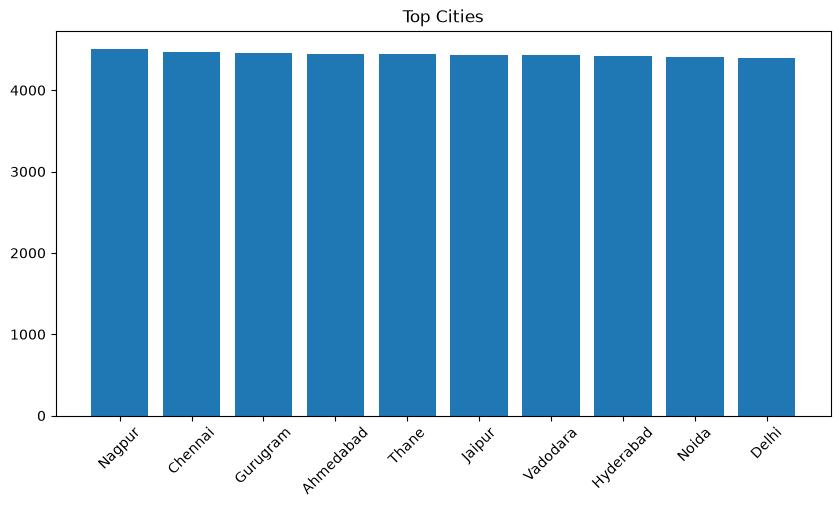

In [21]:
city = customers["city"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(city.index, city.values)

plt.xticks(rotation=45)

plt.title("Top Cities")

plt.show()

Nearly Equal Distribution: Just like the occupation chart, customer numbers across all top 10 cities are virtually identical—each city has roughly 4,400 to 4,500 customers.

Widespread Reach: The bank has a balanced geographical footprint spanning major Tier-1 and Tier-2 economic hubs across North, West, and South India without over-relying on a single city.

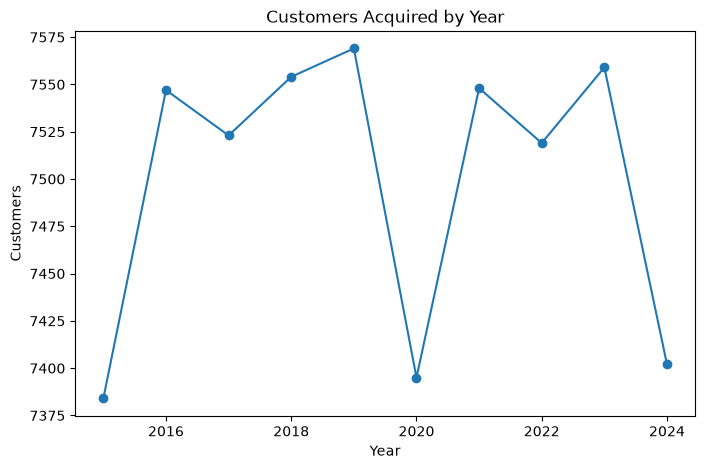

In [22]:
customers["customer_year"] = customers["customer_since"].dt.year

year = customers["customer_year"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(year.index, year.values, marker="o")

plt.title("Customers Acquired by Year")
plt.xlabel("Year")
plt.ylabel("Customers")

plt.show()

Noticeable Dip in 2020: Acquisition dropped sharply in 2020 (likely reflecting the impact of global disruptions/lockdowns), but rebounded quickly in 2021 (~7,548).

Recent Trend (2023–2024): After a strong recovery in 2023 (~7,559), customer acquisition experienced another sharp dip in 2024, falling to around ~7,402.

Steady Baseline: The bank maintains a remarkably stable organic acquisition rate of roughly 7,400 to 7,550 new customers each year.

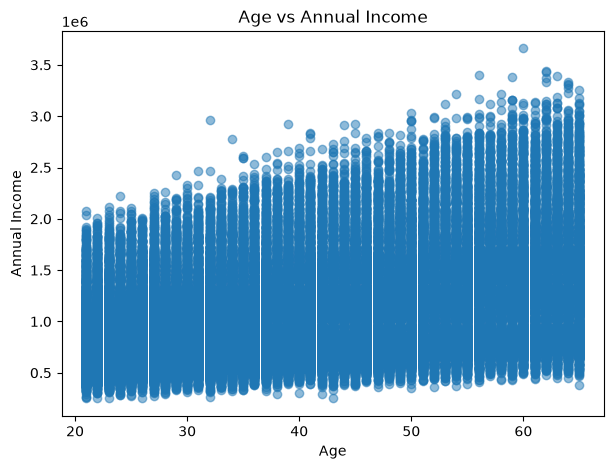

In [23]:
customers[["age","annual_income"]].corr()

plt.figure(figsize=(7,5))

plt.scatter(
    customers["age"],
    customers["annual_income"],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Annual Income")

plt.title("Age vs Annual Income")

plt.show()

Earning Progression: Income growth naturally aligns with career progression—older individuals are more likely to hold senior or executive positions that command top-tier salaries.

Targeted Product Strategy:

Younger Base (20s–30s): Great target for initial credit cards, personal loans, and early savings accounts.

Older Base (40s–60s): High-income earners ideal for premium wealth management, high-value investment portfolios, and retirement planning.